# Ricker Recruitment Model

The Ricker model is a classic discrete-time population model used in fisheries and ecology. Unlike the Beverton-Holt model, the Ricker curve is "hump-shaped," meaning recruitment declines at very high stock densities.

### 1. The Mathematical Equation
There are two common forms. In fisheries (Stock-Recruitment), it is written as:

$$R = \alpha S e^{-\beta S}$$

Where:
* $R$: Recruits.
* $S$: Spawning Stock.
* $\alpha$: Initial productivity (recruits per spawner at low density).
* $\beta$: Density-dependent mortality parameter.

In ecology (Population Dynamics), it is often written as:
$$N_{t+1} = N_t e^{r (1 - \frac{N_t}{K})}$$

### 2. Key Features
* **The Hump:** Recruitment peaks at $S = 1/\beta$ and then falls.
* **Instability:** Because the curve has a steep negative slope at high densities, it can produce **Complex Dynamics** (Oscillations, Cycles, and Chaos) if the growth rate is high.

### 3. Biological Mechanism
This model typically describes species where adults compete directly with or cannibalize their offspring (e.g., Salmon, Cod, or insects).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:

def ricker_model(S, alpha, beta):
    """
    Fisheries Form: R = alpha * S * exp(-beta * S)
    """
    return alpha * S * np.exp(-beta * S)

def ricker_ecology_step(N, r, K):
    """
    Ecology Form: N_next = N * exp(r * (1 - N/K))
    """
    return N * np.exp(r * (1 - N / K))

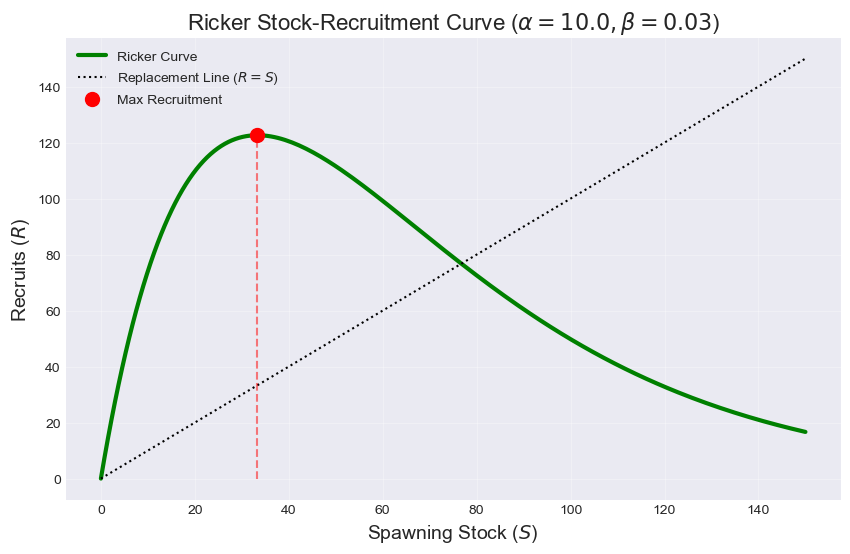

In [4]:
# --- Parameters ---
S = np.linspace(0, 150, 200)
alpha = 10.0
beta = 0.03

# Calculate R
R = ricker_model(S, alpha, beta)

# Find Peak
peak_S = 1 / beta
peak_R = ricker_model(peak_S, alpha, beta)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Ricker Curve
ax.plot(S, R, 'g-', linewidth=3, label='Ricker Curve')

# 2. Replacement Line (R=S)
ax.plot(S, S, 'k:', label='Replacement Line ($R=S$)')

# 3. Peak Marker
ax.plot(peak_S, peak_R, 'ro', markersize=10, label='Max Recruitment')
ax.vlines(peak_S, 0, peak_R, linestyles='--', color='r', alpha=0.5)

ax.set_title(f'Ricker Stock-Recruitment Curve ($\\alpha={alpha}, \\beta={beta}$)', fontsize=16)
ax.set_xlabel('Spawning Stock ($S$)', fontsize=14)
ax.set_ylabel('Recruits ($R$)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

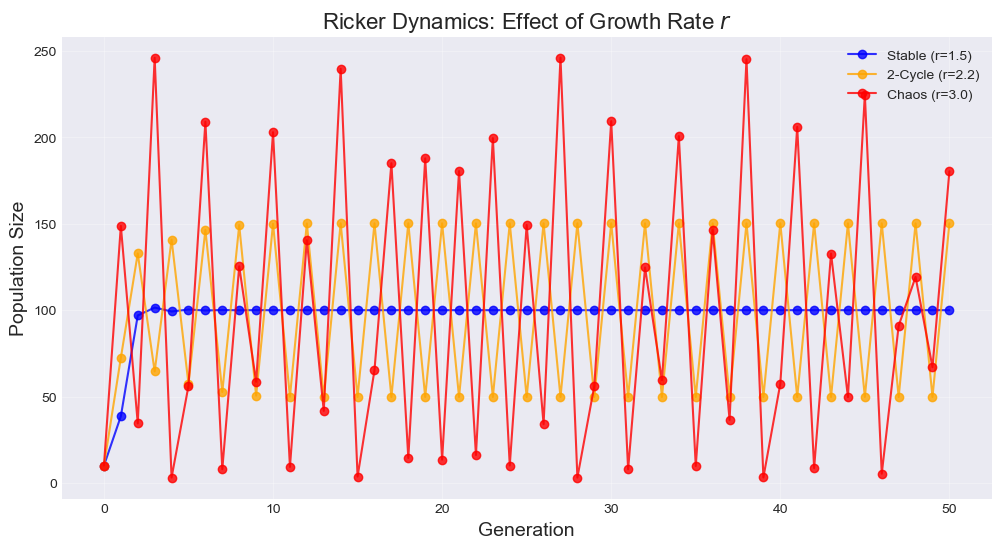

In [5]:
# --- Parameters ---
generations = 50
K = 100
initial_N = 10

r_values = [1.5, 2.2, 3.0]
labels = ['Stable (r=1.5)', '2-Cycle (r=2.2)', 'Chaos (r=3.0)']
colors = ['blue', 'orange', 'red']

# --- Simulation & Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

for r, label, color in zip(r_values, labels, colors):
    pop = [initial_N]
    for t in range(generations):
        next_n = ricker_ecology_step(pop[-1], r, K)
        pop.append(next_n)
    
    ax.plot(pop, marker='o', linestyle='-', linewidth=1.5, label=label, color=color, alpha=0.8)

ax.set_title('Ricker Dynamics: Effect of Growth Rate $r$', fontsize=16)
ax.set_xlabel('Generation', fontsize=14)
ax.set_ylabel('Population Size', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

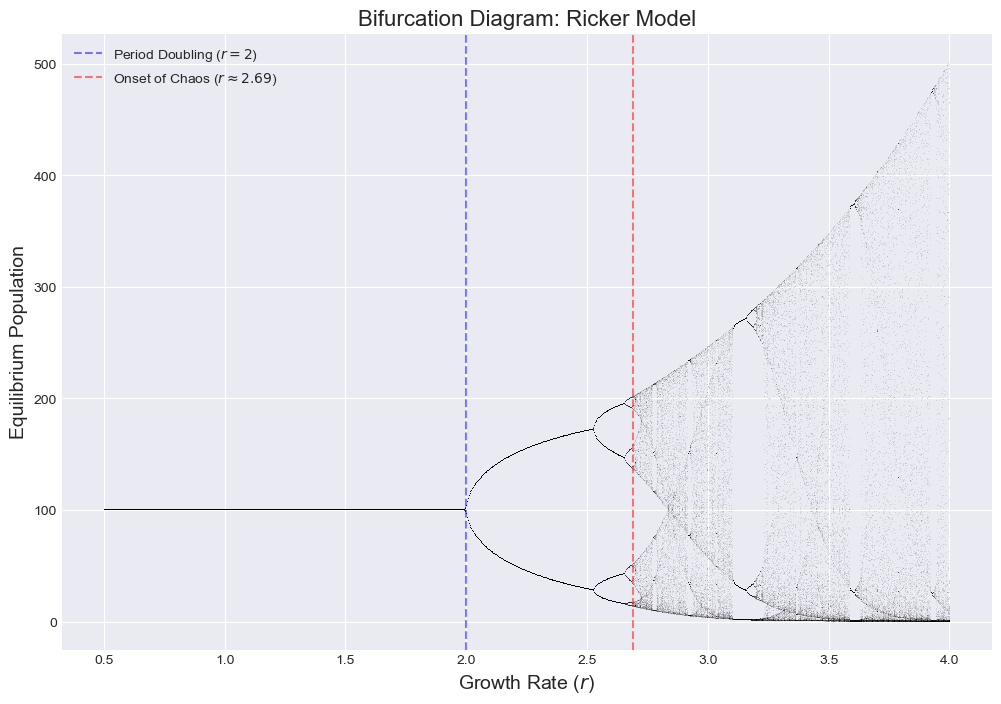

In [7]:
# --- Parameters ---
r_min, r_max = 0.5, 4.0
n_r = 1000             # Resolution of r
r_range = np.linspace(r_min, r_max, n_r)

iterations = 500       # Total steps per r
last = 100             # How many final steps to record (to catch cycles)
K = 100

# --- Simulation Loop ---
fig, ax = plt.subplots(figsize=(12, 8))

# We iterate over every 'r' value
for r in r_range:
    x = 10 # Initial population
    
    # Burn-in phase (discard transients)
    for _ in range(iterations - last):
        x = ricker_ecology_step(x, r, K)
        
    # Recording phase
    results = []
    for _ in range(last):
        x = ricker_ecology_step(x, r, K)
        results.append(x)
        
    # Plot these points for this specific r
    ax.plot([r]*last, results, ',k', alpha=0.1) # ',' is a pixel marker

ax.set_title('Bifurcation Diagram: Ricker Model', fontsize=16)
ax.set_xlabel('Growth Rate ($r$)', fontsize=14)
ax.set_ylabel('Equilibrium Population', fontsize=14)
ax.axvline(2.0, color='b', linestyle='--', alpha=0.5, label='Period Doubling ($r=2$)')
ax.axvline(2.692, color='r', linestyle='--', alpha=0.5, label='Onset of Chaos ($r\\approx 2.69$)')
ax.legend()

plt.show()